# 第074课 真实执行实验

混合模型：逐步计算责任和参数，检查重启与退化。

本Notebook读取经摘要核验的原创CSV，真正执行算法；冻结输出便于离线阅读。建议重启内核后Run All。

In [1]:
import numpy as np  # 数组运算库。
from common import load_data  # 同时核验摘要和生成器字节。
data = load_data()  # 读取本讲数据，不访问网络。
print({name: len(rows['id']) for name, rows in data.items()})  # 核对对象数量。

{'train': 360, 'audit': 240}


## 先预测，再算小例子

请先在纸上写出预期，再执行下一格；讲义和答案册解释每项。

In [2]:
from mixture import expectation, maximization  # 两步各自可调用。
x = np.array([-1., 0., 1.])  # 手算的三个测量。
r, before = expectation(x, [.5, .5], [-1., 1.], [1., 1.])  # 先固定旧参数。
w, m, v = maximization(x, r)  # 再按软权重更新。
print(r, w, m, v, before, expectation(x, w, m, v)[1])  # 显示真实中间值。

[[0.88079708 0.11920292]
 [0.5        0.5       ]
 [0.11920292 0.88079708]] [0.5 0.5] [-0.50772944  0.50772944] [0.40887749 0.40887749] -4.389253938647964 -3.5492151091779762


## 执行完整冻结协议

下面调用run重新计算所有结果，未直接用冻结JSON充当实验输出。

In [3]:
from experiment import run  # 导入本讲完整实验。
report = run()  # 实际执行拟合、对照与评价。
print(report['hand'])
print([(v['initial_means'], v['history'][-1], v['converged']) for v in report['runs']])
print(report['collapse'])

{'responsibilities': [[0.8807970779778824, 0.11920292202211759], [0.49999999999999994, 0.49999999999999994], [0.11920292202211759, 0.8807970779778824]], 'weights': [0.5, 0.5], 'means': [-0.5077294373038432, 0.5077294373038432], 'variances': [0.40887748516178934, 0.4088774851617894], 'old_ll': -4.389253938647964, 'new_ll': -3.5492151091779762}
[([-3, 0, 3], -687.0915449955642, True), ([-3, -2.8, -2.6], -687.0915449956724, True), ([0, 0, 0], -819.5512605575402, True), ([0.351668154289, -3.1567850442, 2.096293396364], -687.0915449956551, True), ([2.771713596589, -0.880033562219, -3.183494930362], -687.0915449956301, True), ([0.796634681195, 0.515972924895, -2.935280098322], -687.0915449955701, True), ([-0.73389400028, 0.62713254354, -0.530010503916], -687.0915449957466, True), ([2.939213912004, -0.511699619256, 2.689876847705], -687.0915449956085, True)]
[{'variance': 1.0, 'log_likelihood': -5.538337826759914}, {'variance': 0.1, 'log_likelihood': -4.5080641732695375}, {'variance': 0.01, '

## 保存本次重算结果并核对性质

显式测试含独立实现、数学恒等式和必要边界，错误会抛出异常。

In [4]:
from common import write_json  # 保存便于追查的本次结果。
write_json('outputs/notebook/result.json', report)  # 不覆盖公开冻结报告。
import subprocess, sys  # 新进程运行显式测试。
completed = subprocess.run([sys.executable, 'test_experiment.py', '--report', 'outputs/notebook/result.json', '--out', 'outputs/notebook/tests.json'], check=True, capture_output=True, text=True)
print('本次Notebook重算结果已通过显式测试。')

本次Notebook重算结果已通过显式测试。


## 重新绘图并内嵌

图从本次重算报告与原创数据生成。中文图题及每个坐标含义见讲义对应段落。

01_density.png


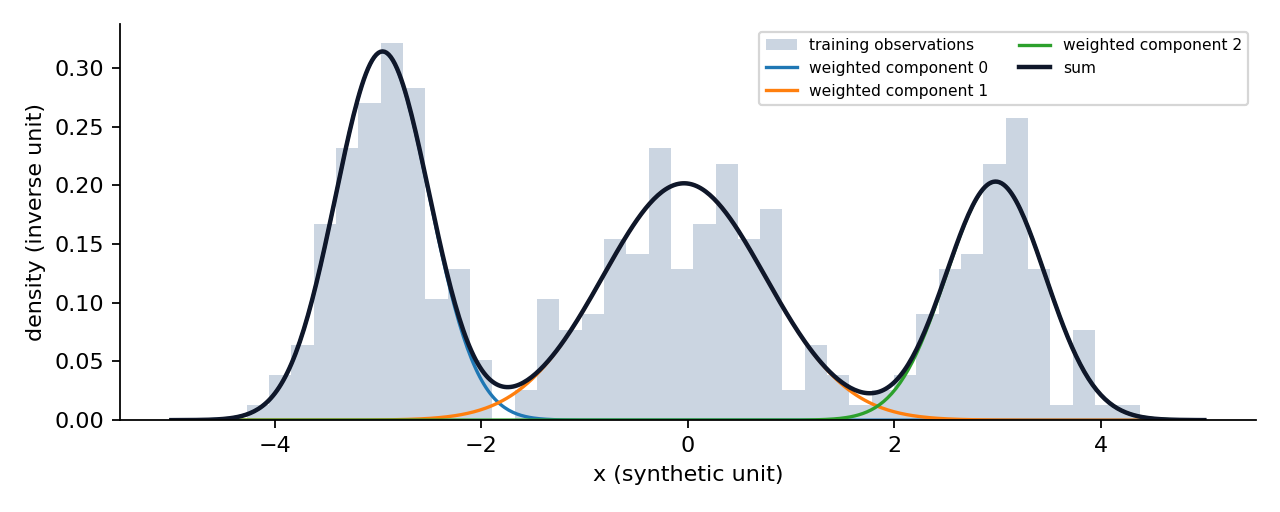

02_responsibility.png


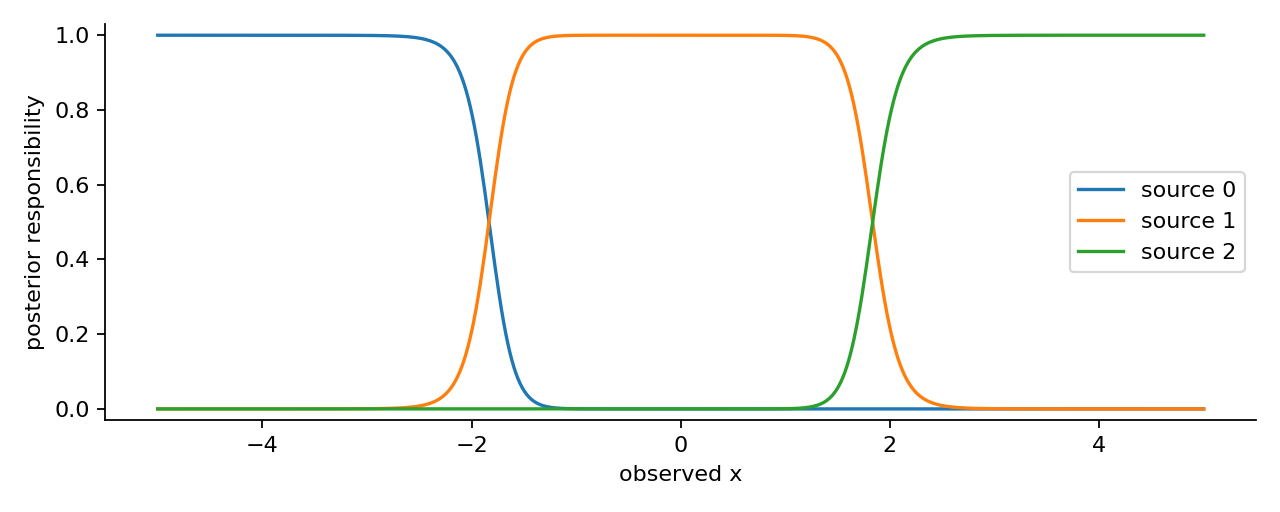

03_restarts.png


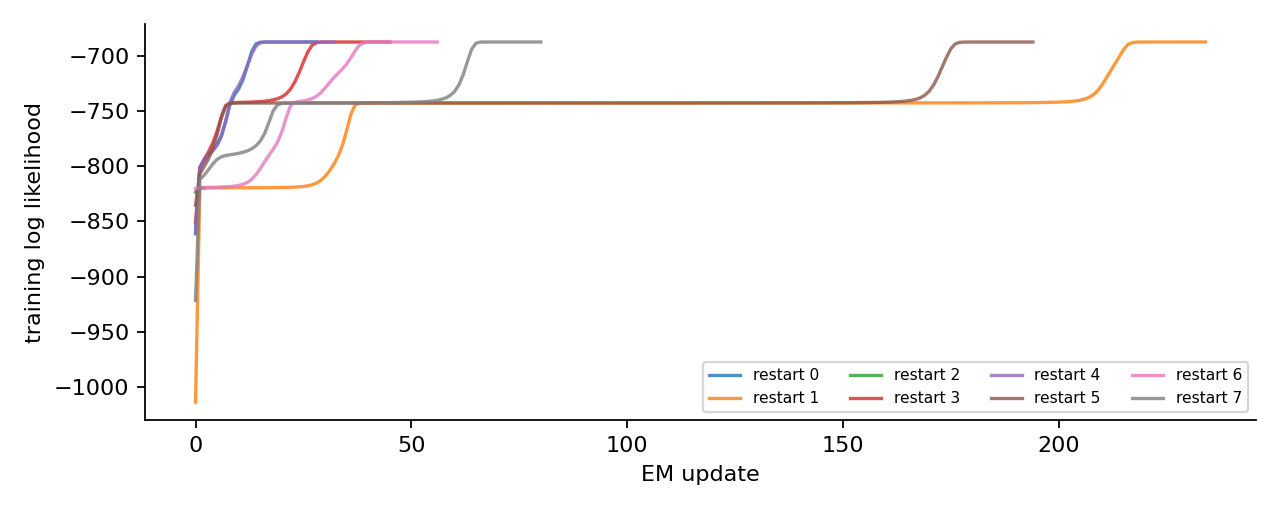

04_collapse.png


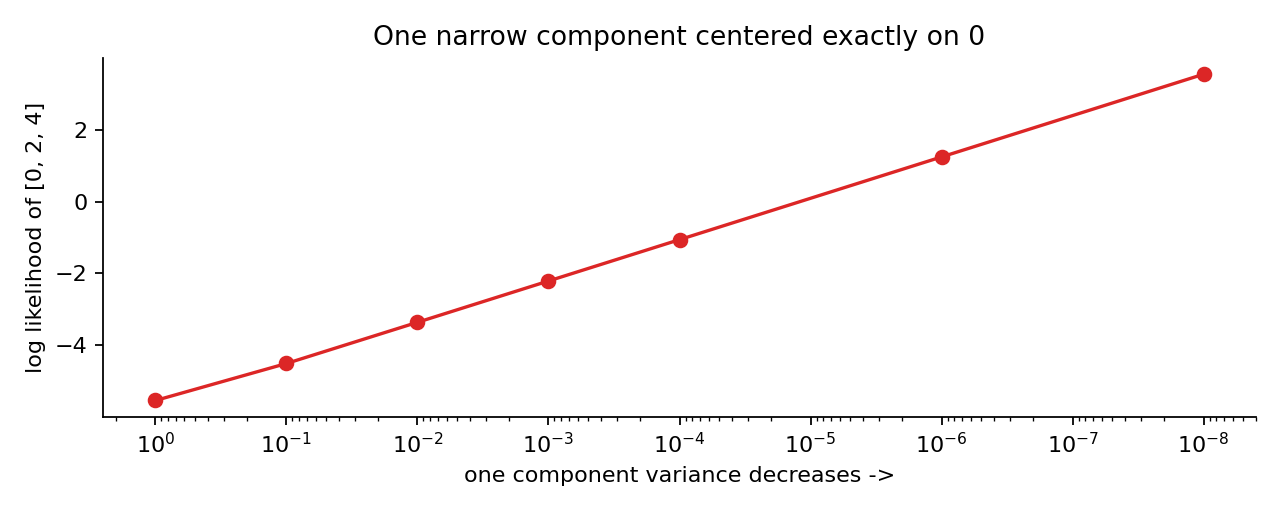

In [5]:
subprocess.run([sys.executable, 'plots.py', '--report', 'outputs/notebook/result.json', '--directory', 'outputs/notebook/figures'], check=True, capture_output=True, text=True)  # 独立绘图进程。
from pathlib import Path  # 枚举生成图。
from IPython.display import display, Image  # 嵌入PNG，不依赖外部链接。
for path in sorted(Path('outputs/notebook/figures').glob('*.png')):
    print(path.name)  # 文件名帮助对应讲义图题。
    display(Image(filename=str(path)))  # 图像数据保存在执行输出内。

## 写下你的边界声明

用一句话说明本实验已支持什么，再用一句话说明尚不能据此推出什么。请对照独立答案册，而不是只写“测试通过”。

执行验证不包含Jupyter浏览器界面和外部socket内核传输；本Notebook采用新Python进程中的真实IPython计算内核。